In [5]:
!pip show tensorflow keras keras-preprocessing

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\Administrator\anaconda3\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 
---
Name: keras
Version: 3.12.0
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: C:\Users\Administrator\anaconda3\Lib\site-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: tensorflow
---
Name: Keras-Preprocessing
Version: 1.1.2
Summary: Easy data preprocessing and data augmentation for deep learning models
Home-page: https://githu

In [7]:
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
# from keras.preprocessing.image import ImageDataGenerator
# Source - https://stackoverflow.com/a/78145849
# Posted by Ajay Tom, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-09, License - CC BY-SA 4.0

from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [8]:
train_gen=ImageDataGenerator(rescale=1./255)
train_data=train_gen.flow_from_directory('afhq/train',target_size=(128,128),batch_size=32,class_mode='categorical',shuffle=True) 
test_gen=ImageDataGenerator(rescale=1./255)
test_data=test_gen.flow_from_directory('afhq/val',target_size=(128,128),batch_size=1,class_mode='categorical',shuffle=False)

Found 14630 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


In [9]:
# Create a Sequential model
classifier_model = Sequential()

# Convolutional layers
classifier_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3), name="line"))
classifier_model.add(MaxPooling2D((2, 2)))
classifier_model.add(Conv2D(64, (3, 3), activation='relu', name="segment"))
classifier_model.add(MaxPooling2D((2, 2)))
classifier_model.add(Conv2D(128, (3, 3), activation='relu', name="region"))
classifier_model.add(MaxPooling2D((2, 2)))
classifier_model.add(Conv2D(256, (3, 3), activation='relu', name="surface"))
classifier_model.add(MaxPooling2D((2, 2)))
classifier_model.add(Conv2D(512, (3, 3), activation='relu', name="contour"))
classifier_model.add(MaxPooling2D((2, 2)))

# Flatten the feature maps
classifier_model.add(Flatten())

# Fully connected layers
classifier_model.add(Dense(128, activation='relu', name="face"))
classifier_model.add(Dropout(0.5))  # Dropout for regularization
classifier_model.add(Dense(3, activation='softmax', name="species"))  # Adjust the output size based on the number of classes

C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
classifier_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ line (Conv2D)                        │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ segment (Conv2D)                     │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ region (Conv2D)                      │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ surface (Conv2D)                     │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ contour (Conv2D)                     │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ face (Dense)                         │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ species (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,831,235 (6.99 MB)

 Trainable params: 1,831,235 (6.99 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
classifier_model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [12]:
classifier_model.fit(train_data,epochs=10,batch_size = 64)

Epoch 1/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 300s 649ms/step - accuracy: 0.7871 - loss: 0.4820
Epoch 2/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 202s 441ms/step - accuracy: 0.9527 - loss: 0.1398
Epoch 3/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 196s 428ms/step - accuracy: 0.9768 - loss: 0.0729
Epoch 4/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 195s 426ms/step - accuracy: 0.9825 - loss: 0.0533
Epoch 5/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 204s 446ms/step - accuracy: 0.9869 - loss: 0.0414
Epoch 6/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 196s 428ms/step - accuracy: 0.9895 - loss: 0.0309
Epoch 7/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 197s 429ms/step - accuracy: 0.9909 - loss: 0.0281
Epoch 8/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 197s 431ms/step - accuracy: 0.9887 - loss: 0.0364
Epoch 9/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 198s 432ms/step - accuracy: 0.9929 - loss: 0.0186
Epoch 10/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 197s 431ms/step - accuracy: 0.9913 - loss: 0.0271


In [13]:
classifier_model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ line (Conv2D)                        │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ segment (Conv2D)                     │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ region (Conv2D)                      │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ surface (Conv2D)                     │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ contour (Conv2D)                     │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ face (Dense)                         │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ species (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,493,707 (20.96 MB)

 Trainable params: 1,831,235 (6.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,662,472 (13.97 MB)

In [14]:
pred=classifier_model.predict(test_data).argmax(axis=1)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step


In [15]:
from sklearn.metrics import classification_report

In [16]:
print(classification_report(pred ,test_data.classes ))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       482
           1       0.96      0.98      0.97       491
           2       0.99      0.94      0.96       527

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



In [17]:
classifier_model.save("animal_classifier_model.h5")

NameError: name 'history' is not defined

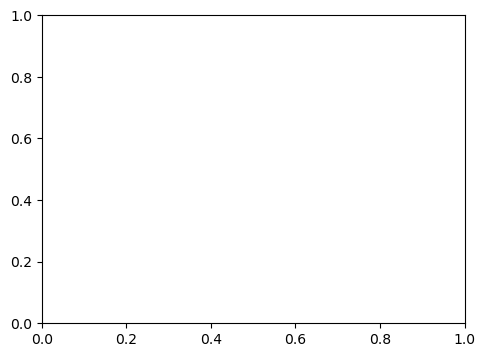

In [18]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Class labels: ['cat', 'dog', 'wild']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


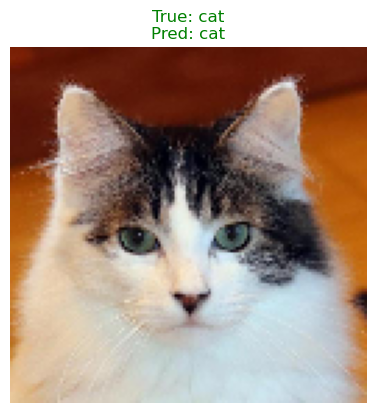

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

# 1. Load your trained model (adjust the path if needed)
model = load_model("animal_classifier_model.h5")  # or use your existing model variable

# 2. Get class names from the generator (folder names)
class_labels = list(test_data.class_indices.keys())  # e.g., ['angry', 'happy', 'sad']
print("Class labels:", class_labels)

# 3. Get one batch of images and labels from test_data
images, labels = next(test_data)  # images shape: (batch_size, 128, 128, 3)

# 4. Make predictions
predictions = model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

# 5. Display the images with true and predicted labels
plt.figure(figsize=(15, 8))
for i in range(min(len(images), 8)):  # show up to 8 images
    plt.subplot(2, 4, i+1)
    img = images[i].astype('float32')  # already normalized
    plt.imshow(img)
    true_label = class_labels[true_classes[i]]
    pred_label = class_labels[predicted_classes[i]]
    color = 'green' if true_classes[i] == predicted_classes[i] else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()